<a href="https://colab.research.google.com/github/Trishacrypto/AI-Bank-Fraud-Detection/blob/main/bank_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost shap imbalanced-learn

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Trishacrypto/AI-Bank-Fraud-Detection/blob/main/bank_fraud_detection.ipynb)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import shap

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Bank_Transaction_Fraud_Detection.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 168877
Number of columns: 24


In [ ]:
display(df.head())

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168877 entries, 0 to 168876
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              168877 non-null  object 
 1   Customer_Name            168877 non-null  object 
 2   Gender                   168877 non-null  object 
 3   Age                      168877 non-null  int64  
 4   State                    168877 non-null  object 
 5   City                     168877 non-null  object 
 6   Bank_Branch              168877 non-null  object 
 7   Account_Type             168877 non-null  object 
 8   Transaction_ID           168877 non-null  object 
 9   Transaction_Date         168877 non-null  object 
 10  Transaction_Time         168877 non-null  object 
 11  Transaction_Amount       168877 non-null  float64
 12  Merchant_ID              168877 non-null  object 
 13  Transaction_Type         168877 non-null  object 
 14  Merc

In [ ]:
df.describe()

,Age,Transaction_Date,Transaction_Time,Transaction_Amount,Account_Balance,Is_Fraud,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Is_Weekend,Amount_to_Balance
count,168877.000000,168877,168877,168877.000000,168877.000000,168877.000000,168877.0,168877.0,168877.000000,168877.000000,168877.000000,168877.000000,168877.000000,168877.000000
mean,44.011920,2025-01-15 12:24:53.659882752,2026-09-15 11:58:49.340644096,49556.299575,52472.875702,0.050682,2025.0,1.0,15.517288,2.969801,11.481048,29.467352,0.267609,1.565399
min,18.000000,2025-01-01 00:00:00,2026-09-15 00:00:00,10.290000,5000.820000,0.000000,2025.0,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000145
25%,31.000000,2025-01-08 00:00:00,2026-09-15 06:00:12,24961.890000,28771.010000,0.000000,2025.0,1.0,8.000000,1.000000,6.000000,15.000000,0.000000,0.471764
50%,44.000000,2025-01-16 00:00:00,2026-09-15 11:58:11,49482.820000,52419.410000,0.000000,2025.0,1.0,16.000000,3.000000,11.000000,29.000000,0.000000,0.943983
75%,57.000000,2025-01-23 00:00:00,2026-09-15 17:57:16,74244.800000,76205.680000,0.000000,2025.0,1.0,23.000000,5.000000,17.000000,44.000000,1.000000,1.736017
max,70.000000,2025-01-31 00:00:00,2026-09-15 23:59:59,98999.980000,99999.950000,1.000000,2025.0,1.0,31.000000,6.000000,23.000000,59.000000,1.000000,19.644646
std,15.278921,NaN,NaN,28517.075530,27405.228178,0.219348,0.0,0.0,8.671779,1.938993,6.910693,17.277050,0.442714,2.032356


In [ ]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email', 'Transaction_Year', 'Transaction_Month',
       'Transaction_Day', 'Transaction_DayOfWeek', 'Transaction_Hour',
       'Transaction_Minute', 'Is_Weekend', 'Amount_to_Balance', 'Age_Group'],
      dtype='object')

In [ ]:
df.tail()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Customer_Email,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Is_Weekend,Amount_to_Balance,Age_Group
168872,efb4315c-f8fe-4cab-801f-ef54e2c14b35,Nirja Mander,Male,31,Haryana,Faridabad,Faridabad Branch,Checking,069425a3-c40c-4827-9e65-be78d91656c7,2025-01-26,...,nirjaXXXXX@XXXXXX.com,2025,1,26,6,0,38,1,0.339026,Adult
168873,12b5a10c-ed7b-47f6-8081-0c7222a49c1a,Rehaan Salvi,Male,36,Puducherry,Yanam,Yanam Branch,Business,330f8872-92f9-4a6c-ad2b-f8786149cd84,2025-01-08,...,rehaanXXX@XXXXXX.com,2025,1,8,2,22,53,0,0.380830,Adult
168874,e6b448d8-874d-45b6-974d-80ae94a6bf50,Amruta Dugar,Female,53,Jharkhand,Hazaribagh,Hazaribagh Branch,Savings,3720f551-3e8e-4162-8455-02be7e5f9d84,2025-01-19,...,amrutaXXXXX@XXXXXXX.com,2025,1,19,6,17,56,1,1.488006,Middle_Age
168875,b562045e-2a94-4c24-a340-7107186e2d92,Rayaan Kapadia,Female,69,West Bengal,Asansol,Asansol Branch,Business,2c8c49da-db0e-4956-a369-ec21ba62d940,2025-01-08,...,rayaanXXXXX@XXXXXX.com,2025,1,8,2,13,40,0,0.242914,Senior
168876,c24d55fb-4a57-4566-9e60-a5267f9d9129,Turvi Luthra,Male,25,West Bengal,Kolkata,Kolkata Branch,Checking,5e70d015-aeb4-4e77-b804-a552f6068493,2025-01-04,...,NaN,2025,1,4,5,15,13,1,1.564274,Young


In [ ]:
len(df)

168877

In [ ]:
df["Age"].mean()

np.float64(44.011919918046864)

In [ ]:
df["Age"]>30

,Age
0,True
1,True
2,False
3,True
4,True
...,...
168872,True
168873,True
168874,True
168875,True


In [ ]:
df[df["Age"]>30]

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Customer_Email,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Is_Weekend,Amount_to_Balance,Age_Group
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,2025-01-23,...,oshaXXXXX@XXXXX.com,2025,1,23,3,16,4,0,0.434767,Middle_Age
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,2025-01-11,...,hredhaanXXXX@XXXXXX.com,2025,1,11,5,17,14,1,0.584568,Middle_Age
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,2025-01-19,...,yaminiXXXXX@XXXXXXX.com,2025,1,19,6,12,27,1,0.240653,Middle_Age
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,2025-01-30,...,kritikaXXXX@XXXXXX.com,2025,1,30,3,18,30,0,1.138154,Middle_Age
5,6c870d65-76b0-431d-bdf3-9292998e8211,Ishanvi Dar,Male,54,Gujarat,Ahmedabad,Ahmedabad Branch,Checking,af5f667c-d064-4083-bfb7-83396111a3da,2025-01-25,...,ishanviXXX@XXXXX.com,2025,1,25,5,6,49,1,0.158524,Middle_Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168871,0092f90e-5b54-44b5-8a64-884dde236a11,Warhi Rama,Female,45,Delhi,North Delhi,North Delhi Branch,Checking,423ce753-8232-423c-988e-faf4edc593a3,2025-01-13,...,warhiXXX@XXXXX.com,2025,1,13,0,4,57,0,9.734723,Middle_Age
168872,efb4315c-f8fe-4cab-801f-ef54e2c14b35,Nirja Mander,Male,31,Haryana,Faridabad,Faridabad Branch,Checking,069425a3-c40c-4827-9e65-be78d91656c7,2025-01-26,...,nirjaXXXXX@XXXXXX.com,2025,1,26,6,0,38,1,0.339026,Adult
168873,12b5a10c-ed7b-47f6-8081-0c7222a49c1a,Rehaan Salvi,Male,36,Puducherry,Yanam,Yanam Branch,Business,330f8872-92f9-4a6c-ad2b-f8786149cd84,2025-01-08,...,rehaanXXX@XXXXXX.com,2025,1,8,2,22,53,0,0.380830,Adult
168874,e6b448d8-874d-45b6-974d-80ae94a6bf50,Amruta Dugar,Female,53,Jharkhand,Hazaribagh,Hazaribagh Branch,Savings,3720f551-3e8e-4162-8455-02be7e5f9d84,2025-01-19,...,amrutaXXXXX@XXXXXXX.com,2025,1,19,6,17,56,1,1.488006,Middle_Age


In [ ]:
df[df["Account_Type"]=="Savings"]

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Customer_Email,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Is_Weekend,Amount_to_Balance,Age_Group
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,2025-01-23,...,oshaXXXXX@XXXXX.com,2025,1,23,3,16,4,0,0.434767,Middle_Age
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,2025-01-25,...,ekaniXXX@XXXXXX.com,2025,1,25,5,3,9,1,0.943782,Young
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,2025-01-30,...,kritikaXXXX@XXXXXX.com,2025,1,30,3,18,30,0,1.138154,Middle_Age
10,87b53799-9959-4534-9aad-f7dfc1821d4b,Charvi Biswas,Male,18,Gujarat,Vadodara,Vadodara Branch,Savings,72832f5f-3b4c-4c9f-8434-8cfc564835f1,2025-01-25,...,charviXXXX@XXXXXXX.com,2025,1,25,5,8,52,1,1.789031,Young
12,b2563484-0dae-4555-8859-5b55f91136d4,Amara Sidhu,Male,66,Mizoram,Champhai,Champhai Branch,Savings,6fa60ddb-b48b-40d3-b48a-d3bfa5afaafa,2025-01-27,...,amaraXXXX@XXXXXXX.com,2025,1,27,0,22,2,0,1.221061,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168863,533f0e1b-d8c9-41a4-a41a-79057f74390a,Janya Vora,Female,21,Haryana,Gurugram,Gurugram Branch,Savings,5c9a1f76-97aa-4cd8-a214-d579c8ff2a9c,2025-01-12,...,janyaXXX@XXXXXX.com,2025,1,12,6,0,44,1,0.970242,Young
168866,b0cf8cfd-6877-4d1b-bef9-da5201418401,Jackson Sidhu,Male,62,Manipur,Kangpokpi,Kangpokpi Branch,Savings,48f5718e-d65f-495a-9276-610166c0f836,2025-01-05,...,jacksonXXX@XXXXXX.com,2025,1,5,6,7,49,1,1.312801,Senior
168867,0d364276-7da7-4f1b-8e2f-ef1817dd4571,Shivani Salvi,Female,32,Puducherry,Yanam,Yanam Branch,Savings,4eb639aa-9465-4af4-a63b-4b8b4358e49d,2025-01-03,...,shivaniXXXXX@XXXXXXX.com,2025,1,3,4,10,39,0,0.438727,Adult
168869,06ae20c7-467a-452c-95bb-bc2f9de61ab4,Anthony Chaudhuri,Female,50,Arunachal Pradesh,Tawang,Tawang Branch,Savings,062aac13-c79d-4e57-99a6-42a970e5c855,2025-01-01,...,anthonyXXXXX@XXXXXX.com,2025,1,1,2,22,37,0,0.951291,Middle_Age


In [ ]:
df.sort_values("Age")

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Customer_Email,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Is_Weekend,Amount_to_Balance,Age_Group
43,13d85611-e4c9-4da0-bbe2-60984faa8df7,Nathaniel Baria,Female,18,Assam,Jorhat,Jorhat Branch,Business,ca85aa59-34cb-4031-a97d-f3767358184a,2025-01-28,...,nathanielXXXX@XXXXX.com,2025,1,28,1,13,12,0,0.134693,Young
9370,f41080a2-3f11-47b0-8f3d-21ec531e7cd5,Harini Viswanathan,Male,18,Karnataka,Mangalore,Mangalore Branch,Business,d663f99d-5400-4919-9694-1b62f7de6cab,2025-01-24,...,hariniXXX@XXXXX.com,2025,1,24,4,15,6,0,0.656883,Young
70526,34acdc3a-3882-401b-8ab2-5a24ddb89800,Timothy Acharya,Female,18,Nagaland,Kohima,Kohima Branch,Checking,9bb30437-8384-46f6-b5ba-b858bc7532c8,2025-01-20,...,timothyXXXXX@XXXXX.com,2025,1,20,0,9,28,0,1.134590,Young
12516,7e44b29d-958f-4958-bc80-b202fc034292,Ayushman Kulkarni,Male,18,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Checking,bd5d7d4a-8ad4-480a-8962-7da8be380ec0,2025-01-11,...,ayushmanXXX@XXXXXXX.com,2025,1,11,5,9,59,1,0.491821,Young
86499,d5a3439b-4d7e-41c4-8c71-409726c03175,Dipta Basak,Female,18,Uttarakhand,Haridwar,Haridwar Branch,Savings,eef068bf-7d5e-4bc6-8266-84ab9564e05b,2025-01-04,...,diptaXXXXX@XXXXXX.com,2025,1,4,5,2,33,1,1.139178,Young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83999,ecb9b85f-3c81-4423-b165-ef5ac5013aa5,Falan Yogi,Male,70,Manipur,Kangpokpi,Kangpokpi Branch,Checking,086d1bbd-6148-42f6-a8c2-845ce667d0b9,2025-01-29,...,falanXXX@XXXXXX.com,2025,1,29,2,9,54,0,0.662588,Senior
111870,9743105a-d753-45d6-b141-26a88638c746,Anamika Chand,Male,70,Jharkhand,Jamshedpur,Jamshedpur Branch,Business,80616c38-7485-4340-93c7-481b26219fbd,2025-01-29,...,anamikaXXXX@XXXXX.com,2025,1,29,2,11,44,0,0.600332,Senior
141699,9ee9e4ae-18db-4d47-879e-8ff24b2d14c6,Amrita Atwal,Male,70,Puducherry,Karaikal,Karaikal Branch,Business,b7e5c4a5-6b28-470f-bcb5-2695602e1f1b,2025-01-14,...,amritaXXXXX@XXXXXX.com,2025,1,14,1,5,36,0,0.975869,Senior
68,88c6b7f9-9569-4cb7-8c61-6592d09d2f18,Siya Tak,Male,70,Arunachal Pradesh,Naharlagun,Naharlagun Branch,Checking,23bcc512-e573-42c3-8c97-24d945eac077,2025-01-11,...,siyaXXXX@XXXXX.com,2025,1,11,5,4,30,1,1.599734,Senior


In [ ]:
df.isnull()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Customer_Email,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Is_Weekend,Amount_to_Balance,Age_Group
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168872,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
168873,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
168874,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
168875,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
168872,False
168873,False
168874,False
168875,False


In [ ]:
df=df.drop_duplicates()
df

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Customer_Email,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Transaction_Hour,Transaction_Minute,Is_Weekend,Amount_to_Balance,Age_Group
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,2025-01-23,...,oshaXXXXX@XXXXX.com,2025,1,23,3,16,4,0,0.434767,Middle_Age
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,2025-01-11,...,hredhaanXXXX@XXXXXX.com,2025,1,11,5,17,14,1,0.584568,Middle_Age
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,2025-01-25,...,ekaniXXX@XXXXXX.com,2025,1,25,5,3,9,1,0.943782,Young
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,2025-01-19,...,yaminiXXXXX@XXXXXXX.com,2025,1,19,6,12,27,1,0.240653,Middle_Age
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,2025-01-30,...,kritikaXXXX@XXXXXX.com,2025,1,30,3,18,30,0,1.138154,Middle_Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168872,efb4315c-f8fe-4cab-801f-ef54e2c14b35,Nirja Mander,Male,31,Haryana,Faridabad,Faridabad Branch,Checking,069425a3-c40c-4827-9e65-be78d91656c7,2025-01-26,...,nirjaXXXXX@XXXXXX.com,2025,1,26,6,0,38,1,0.339026,Adult
168873,12b5a10c-ed7b-47f6-8081-0c7222a49c1a,Rehaan Salvi,Male,36,Puducherry,Yanam,Yanam Branch,Business,330f8872-92f9-4a6c-ad2b-f8786149cd84,2025-01-08,...,rehaanXXX@XXXXXX.com,2025,1,8,2,22,53,0,0.380830,Adult
168874,e6b448d8-874d-45b6-974d-80ae94a6bf50,Amruta Dugar,Female,53,Jharkhand,Hazaribagh,Hazaribagh Branch,Savings,3720f551-3e8e-4162-8455-02be7e5f9d84,2025-01-19,...,amrutaXXXXX@XXXXXXX.com,2025,1,19,6,17,56,1,1.488006,Middle_Age
168875,b562045e-2a94-4c24-a340-7107186e2d92,Rayaan Kapadia,Female,69,West Bengal,Asansol,Asansol Branch,Business,2c8c49da-db0e-4956-a369-ec21ba62d940,2025-01-08,...,rayaanXXXXX@XXXXXX.com,2025,1,8,2,13,40,0,0.242914,Senior


In [ ]:
#checking the missing value


missing_values = df.isnull().sum()

print("Missing values:")

display(
    missing_values[missing_values > 0]
)

Missing values:


,0
Customer_Email,1


In [ ]:
#checking the duplicate records


print(
    "Number of duplicate rows:",
    df.duplicated().sum()
)

Number of duplicate rows: 0


In [ ]:
#checkinng the fraud distribution

print("Fraud distribution:")

print(
    df["Is_Fraud"].value_counts()
)



Fraud distribution:
Is_Fraud
0    160318
1      8559
Name: count, dtype: int64


In [ ]:
#checking the fraud percentage

fraud_percentage = (
    df["Is_Fraud"].value_counts(normalize=True) * 100
)

print(fraud_percentage)

Is_Fraud
0    94.931814
1     5.068186
Name: proportion, dtype: float64


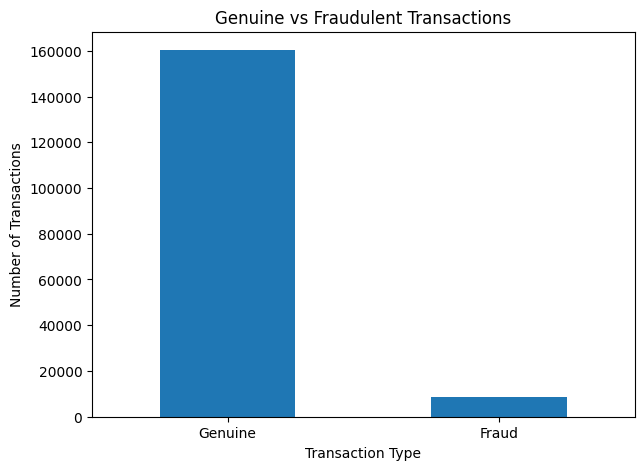

In [ ]:
#visulaizing the fraud distribution

plt.figure(figsize=(7, 5))

df["Is_Fraud"].value_counts().plot(
    kind="bar"
)

plt.title("Genuine vs Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"],
    rotation=0
)

plt.show()

In [ ]:
#now for transactionn_time and transaction_date
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    errors="coerce"
)

df["Transaction_Time"] = pd.to_datetime(
    df["Transaction_Time"],
    errors="coerce"
)

In [ ]:
df["Transaction_Date"]


,Transaction_Date
0,2025-01-23
1,2025-01-11
2,2025-01-25
3,2025-01-19
4,2025-01-30
...,...
168872,2025-01-26
168873,2025-01-08
168874,2025-01-19
168875,2025-01-08


In [ ]:
df["Transaction_Year"] = (
    df["Transaction_Date"].dt.year
)

df["Transaction_Month"] = (
    df["Transaction_Date"].dt.month
)

df["Transaction_Day"] = (
    df["Transaction_Date"].dt.day
)

df["Transaction_DayOfWeek"] = (
    df["Transaction_Date"].dt.dayofweek
)

df["Transaction_Hour"] = (
    df["Transaction_Time"].dt.hour
)

df["Transaction_Minute"] = (
    df["Transaction_Time"].dt.minute
)

In [ ]:
df["Transaction_Year"]


,Transaction_Year
0,2025
1,2025
2,2025
3,2025
4,2025
...,...
168872,2025
168873,2025
168874,2025
168875,2025


In [ ]:
#for creatting the weekend features
df["Is_Weekend"] = (
    df["Transaction_DayOfWeek"] >= 5
).astype(int)

In [ ]:
df["Is_Weekend"]

,Is_Weekend
0,0
1,1
2,1
3,1
4,0
...,...
168872,1
168873,0
168874,1
168875,0


In [ ]:
#for creating the transcation amount feature
df["Amount_to_Balance"] = (
    df["Transaction_Amount"] /
    (df["Account_Balance"] + 1)
)

In [ ]:
df["Amount_to_Balance"]

,Amount_to_Balance
0,0.434767
1,0.584568
2,0.943782
3,0.240653
4,1.138154
...,...
168872,0.339026
168873,0.380830
168874,1.488006
168875,0.242914


In [ ]:
#to create age groups to know the age of the members/customers
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 40, 60, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Age",
        "Senior"
    ]
)

In [ ]:
df["Age_Group"]


,Age_Group
0,Middle_Age
1,Middle_Age
2,Young
3,Middle_Age
4,Middle_Age
...,...
168872,Adult
168873,Adult
168874,Middle_Age
168875,Senior


In [ ]:
X = df.drop(
    "Is_Fraud",
    axis=1
)

y = df["Is_Fraud"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (168877, 32)
Target shape: (168877,)


In [ ]:
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Customer_ID', 'Customer_Name', 'Gender', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Currency', 'Customer_Contact', 'Transaction_Description', 'Customer_Email', 'Age_Group']

Numerical columns:
['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Weekend', 'Amount_to_Balance']


In [ ]:
# Now, perform the train-test split again
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 135101
Testing samples: 33776


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ]
)

# logistics regression
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


In [ ]:
print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [ ]:
# for predicting the logistics

y_pred_logistic = logistic_model.predict(
    X_test
)

y_prob_logistic = logistic_model.predict_proba(
    X_test
)[:, 1]



In [ ]:
y_pred_logistic

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
y_prob_logistic

array([0.08700379, 0.0407686 , 0.06004723, ..., 0.07112088, 0.10541002,
       0.08886521])

In [ ]:
#for evaluating logistic regression
print("LOGISTIC REGRESSION")
print("=" * 45)

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred_logistic
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_logistic,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_pred_logistic,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            y_pred_logistic,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob_logistic
        ),
        4
    )
)

LOGISTIC REGRESSION
Accuracy: 0.9469
Precision: 0.0645
Recall: 0.0035
F1 Score: 0.0066
ROC-AUC: 0.5081


In [ ]:
#creating the random forest
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=15,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
random_forest_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Transaction_Amount',
                                                   'Account_Balance',
                                                   'Is_Weekend',
                                                   'Amount_to_Balance']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Customer_ID',
                                                   'Customer_Name', 'Gender',
                                                   'State', 'City',
                                                   'Bank_Branch',
                                                   'Account_Type',
                                                   'Transaction_ID',
                                                   'Merchant_ID',
                                                   'Transaction_Type',
                                                   'Merchant_Category',
                                                   'Transaction_Device',
                                                   'Transaction_Location',
                                                   'Device_Type',
                                                   'Transaction_Currency',
                                                   'Customer_Contact',
                                                   'Transaction_Description',
                                                   'Customer_Email',
                                                   'Age_Group'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=150, n_jobs=-1,
                                        random_state=42))])

In [ ]:
#training the random forest
print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [ ]:
y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
y_pred_rf

array([0, 0, 0, ..., 0, 1, 0])

In [ ]:
y_prob_rf

array([0.49725658, 0.49865286, 0.49756423, ..., 0.49660744, 0.50117179,
       0.49730515])

In [ ]:
#to evaluate the random forest

print("RANDOM FOREST")
print("=" * 45)

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred_rf
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_rf,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            y_pred_rf,
            zero_division=0
        ),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(
            y_test,
            y_pred_rf,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_prob_rf
        ),
        4
    )
)

RANDOM FOREST
Accuracy: 0.9098
Precision: 0.0652
Recall: 0.0584
F1 Score: 0.0616
ROC-AUC: 0.5034


In [ ]:
#XGBOOST

xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
xgb_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Transaction_Amount',
                                                   'Account_Balance',
                                                   'Is_Weekend',
                                                   'Amount_to_Balance']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Customer_ID',
                                                   'Customer_Name', 'Gender',
                                                   'State', 'City',
                                                   'Bank_Branch',
                                                   'Account_Type',
                                                   'Transaction_ID',
                                                   'Merchant_ID',
                                                   'Transaction_Type',
                                                   '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:


print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [ ]:
#using shap ro transform data
preprocessor_fitted = preprocessor.fit(X_train, y_train)
X_test_sample = X_test.iloc[:1000]

X_test_transformed = (
    preprocessor_fitted.transform(
        X_test_sample
    )
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)

Transformed test shape: (1000, 526781)
